# EDA clínica — NHAMCS Emergency Department 2021

**FIAP Tech Challenge Fase 3 — Hospital Triage**

Este notebook começa na coorte já aprovada e materializada por
[`00_data_quality_nhamcs_2021.ipynb`](00_data_quality_nhamcs_2021.ipynb).
Ele não abre os dados brutos, não interpreta códigos sentinela e não repete
validações ou transformações de qualidade.

Seu único objetivo é explorar relações entre apresentação clínica,
diagnóstico, sinais vitais, desfechos e gravidade.

> Os resultados são agregados e não constituem validação clínica para uso
> assistencial.

## Escopo da exploração

A unidade analisada é um atendimento de emergência. O artefato de entrada
contém 10.495 visitas e inclui campos pós-atendimento somente para análise
retrospectiva. Nenhuma transformação de qualidade é realizada abaixo.

In [1]:
from pathlib import Path
import json
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("ggplot")
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 50)


def plot_percentage_heatmap(
    frame: pd.DataFrame,
    *,
    ax: plt.Axes,
    cmap: str,
    title: str,
    annotation_color: str = "black",
) -> None:
    matrix = frame.to_numpy(dtype=float)
    image = ax.imshow(
        matrix,
        aspect="auto",
        cmap=cmap,
        vmin=0,
        vmax=1,
    )
    ax.set_xticks(
        range(frame.shape[1]),
        labels=frame.columns,
        rotation=30,
        ha="right",
    )
    ax.set_yticks(range(frame.shape[0]), labels=frame.index)
    for row_index in range(frame.shape[0]):
        for column_index in range(frame.shape[1]):
            value = matrix[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{value:.0%}",
                ha="center",
                va="center",
                color=annotation_color,
            )
    ax.set_title(title)
    plt.colorbar(image, ax=ax, label="Proportion")


execution_root = Path.cwd().resolve()
if not (execution_root / "data").exists():
    execution_root = execution_root.parent
EDA_DATABASE_PATH = (
    execution_root
    / "data"
    / "processed"
    / "nhamcs_2021_eda.db"
)
if not EDA_DATABASE_PATH.exists():
    raise FileNotFoundError(
        "Artefato de EDA ausente. Execute primeiro "
        "`notebooks/00_data_quality_nhamcs_2021.ipynb`."
    )

with sqlite3.connect(EDA_DATABASE_PATH) as connection:
    metadata_frame = pd.read_sql_query(
        "SELECT key, value FROM metadata",
        connection,
    )
    data = pd.read_sql_query(
        "SELECT * FROM eda_visits ORDER BY visit_row",
        connection,
    )

artifact_metadata = dict(
    metadata_frame[["key", "value"]].itertuples(index=False, name=None)
)
if artifact_metadata.get("schema_version") != "1":
    raise ValueError("Versão incompatível do artefato de EDA.")
if int(artifact_metadata["row_count"]) != len(data):
    raise ValueError("Contagem de linhas divergente no artefato de EDA.")

TARGET_ORDER = json.loads(artifact_metadata["target_order"])
complaint_columns = json.loads(
    artifact_metadata["complaint_description_columns"]
)
TARGET_COLORS = {
    "normal": "#2ca02c",
    "atencao": "#ffbf00",
    "urgente": "#d62728",
}
data["target"] = pd.Categorical(
    data["target"],
    categories=TARGET_ORDER,
    ordered=True,
)

print(f"Artefato: {EDA_DATABASE_PATH}")
print(f"Visitas disponíveis para EDA: {len(data):,}")
data.shape

Artefato: /Users/cassiojr/FIAP/Tech Challenge 3/data/processed/nhamcs_2021_eda.db
Visitas disponíveis para EDA: 10,495


(10495, 40)

## 1. Distribuição da gravidade

,rows,rate
target,,
normal,3186,30.36%
atencao,5429,51.73%
urgente,1880,17.91%


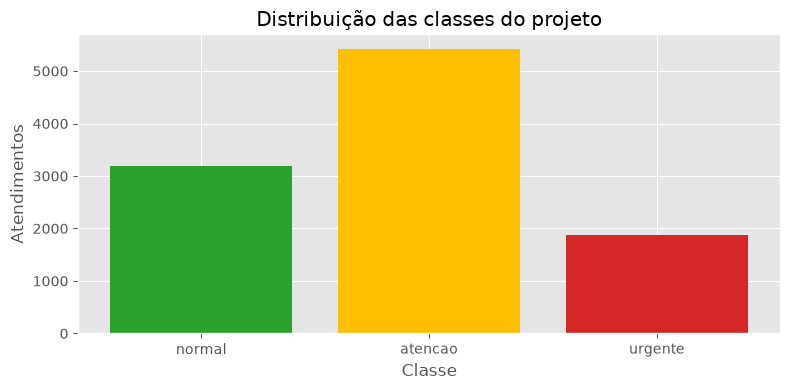

Razão entre a maior e a menor classe: 2.89x


In [2]:
target_distribution = (
    data["target"]
    .value_counts(sort=False)
    .rename("rows")
    .to_frame()
)
target_distribution["rate"] = target_distribution["rows"] / len(data)
display(target_distribution.style.format({"rate": "{:.2%}"}))

fig, ax = plt.subplots(figsize=(8, 4))
target_plot = target_distribution.reset_index()
ax.bar(
    target_plot["target"].astype(str),
    target_plot["rows"],
    color=[TARGET_COLORS[str(target)] for target in target_plot["target"]],
)
ax.set(title="Distribuição das classes do projeto", xlabel="Classe", ylabel="Atendimentos")
plt.tight_layout()
plt.show()

imbalance_ratio = target_distribution["rows"].max() / target_distribution["rows"].min()
print(f"Razão entre a maior e a menor classe: {imbalance_ratio:.2f}x")

## 2. Sintomas e motivos da visita por gravidade

Uma mesma queixa pode ocorrer em várias gravidades. Frequência mede
prevalência; a proporção de `urgente` destaca associações, sem implicar
causalidade ou substituir protocolo clínico.

target,total,normal,atencao,urgente,urgente_rate
complaint,,,,,
"Abdominal pain, cramps, spasms, NOS",1039,95,840,104,10.0%
Shortness of breath,925,103,505,317,34.3%
Chest pain,830,75,457,298,35.9%
Vomiting,802,157,556,89,11.1%
Nausea,797,99,586,112,14.1%
Cough,787,289,376,122,15.5%
"Headache, pain in head",692,165,438,89,12.9%
Fever,669,273,297,99,14.8%
"Accident, NOS",575,202,281,92,16.0%


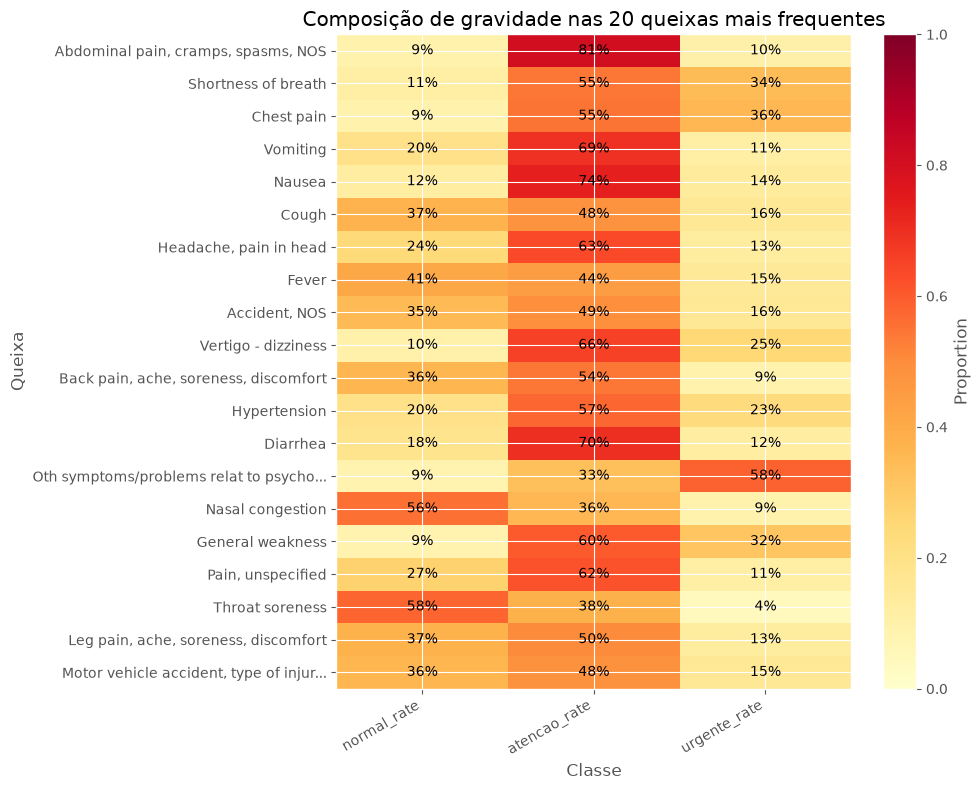

In [3]:
complaints_long = (
    data
    .melt(
        id_vars=["visit_row", "target"],
        value_vars=complaint_columns,
        value_name="complaint",
    )
    .dropna(subset=["complaint"])
)

complaint_counts = pd.crosstab(complaints_long["complaint"], complaints_long["target"])
complaint_counts = complaint_counts.reindex(columns=TARGET_ORDER, fill_value=0)
complaint_summary = complaint_counts.assign(total=complaint_counts.sum(axis=1))
for target in TARGET_ORDER:
    complaint_summary[f"{target}_rate"] = (
        complaint_summary[target] / complaint_summary["total"]
    )

top_complaints = complaint_summary.nlargest(20, "total")
display(
    top_complaints[["total", *TARGET_ORDER, "urgente_rate"]]
    .style.format({"urgente_rate": "{:.1%}"})
)

fig, ax = plt.subplots(figsize=(10, 8))
plot_percentage_heatmap(
    top_complaints[[f"{target}_rate" for target in TARGET_ORDER]],
    ax=ax,
    cmap="YlOrRd",
    title="Composição de gravidade nas 20 queixas mais frequentes",
)
ax.set(xlabel="Classe", ylabel="Queixa")
plt.tight_layout()
plt.show()

In [4]:
high_risk_complaints = (
    complaint_summary.loc[complaint_summary["total"] >= 30]
    .sort_values(["urgente_rate", "total"], ascending=[False, False])
    .head(20)
)
display(
    high_risk_complaints[["total", "normal_rate", "atencao_rate", "urgente_rate"]]
    .style.format({
        "normal_rate": "{:.1%}",
        "atencao_rate": "{:.1%}",
        "urgente_rate": "{:.1%}",
    })
)

target,total,normal_rate,atencao_rate,urgente_rate
complaint,,,,
Oth symptoms/problems relat to psycho...,327,8.6%,33.0%,58.4%
"Disorders of speech, speech disturbance",31,3.2%,38.7%,58.1%
Weakness (neurologic),42,9.5%,33.3%,57.1%
General psychiatric or psychological ...,90,8.9%,34.4%,56.7%
Unconscious on arrival,82,8.5%,35.4%,56.1%
Increased heartbeat,51,7.8%,43.1%,49.0%
Ischemic heart disease,37,16.2%,35.1%,48.6%
Adverse effect of drug abuse,63,4.8%,47.6%,47.6%
Hostile behavior,53,15.1%,39.6%,45.3%


## 3. Doenças diagnosticadas e gravidade

Diagnósticos ajudam a interpretar a coerência clínica do target, mas
são utilizados apenas retrospectivamente nesta análise.

In [5]:
data["primary_diagnosis"] = data["DIAG1_description"].fillna(data["DIAG1_code"])
diagnosis_match_rate = data.loc[data["DIAG1_code"].notna(), "DIAG1_description"].notna().mean()
print(f"Diagnósticos primários resolvidos pela referência ICD-10-CM: {diagnosis_match_rate:.1%}")

diagnosis_counts = pd.crosstab(data["primary_diagnosis"], data["target"])
diagnosis_counts = diagnosis_counts.reindex(columns=TARGET_ORDER, fill_value=0)
diagnosis_summary = diagnosis_counts.assign(total=diagnosis_counts.sum(axis=1))
for target in TARGET_ORDER:
    diagnosis_summary[f"{target}_rate"] = (
        diagnosis_summary[target] / diagnosis_summary["total"]
    )

top_diagnoses = diagnosis_summary.nlargest(20, "total")
display(
    top_diagnoses[["total", *TARGET_ORDER, "urgente_rate"]]
    .style.format({"urgente_rate": "{:.1%}"})
)

high_risk_diagnoses = (
    diagnosis_summary.loc[diagnosis_summary["total"] >= 30]
    .sort_values(["urgente_rate", "total"], ascending=[False, False])
    .head(20)
)
display(
    high_risk_diagnoses[["total", "normal_rate", "atencao_rate", "urgente_rate"]]
    .style.format({
        "normal_rate": "{:.1%}",
        "atencao_rate": "{:.1%}",
        "urgente_rate": "{:.1%}",
    })
)

Diagnósticos primários resolvidos pela referência ICD-10-CM: 99.3%


target,total,normal,atencao,urgente,urgente_rate
primary_diagnosis,,,,,
COVID-19,334,90,181,63,18.9%
"Chest pain, unspecified",298,15,168,115,38.6%
Unspecified abdominal pain,255,28,203,24,9.4%
Pain in joint,194,112,72,10,5.2%
Other chest pain,154,24,92,38,24.7%
Dyspnea,147,8,81,58,39.5%
"Acute upper respiratory infection, unspecified",145,94,43,8,5.5%
Procedure and treatment not carried out because of patient's decision for other and unspecified reasons,139,41,87,11,7.9%
Unspecified injury of face and head,134,47,70,17,12.7%


target,total,normal_rate,atencao_rate,urgente_rate
primary_diagnosis,,,,
Other symptoms and signs involving emotional state,60,1.7%,20.0%,78.3%
Other symptoms and signs involving cognitive functions and awareness,54,7.4%,27.8%,64.8%
"Major depressive disorder, single episode, unspecified",36,5.6%,30.6%,63.9%
Unspecified atrial fibrillation and atrial flutter,35,5.7%,42.9%,51.4%
"Acute kidney failure, unspecified",42,4.8%,47.6%,47.6%
"Heart failure, unspecified",42,7.1%,47.6%,45.2%
"Anemia, unspecified",31,12.9%,41.9%,45.2%
Unspecified convulsions,61,3.3%,52.5%,44.3%
Chronic obstructive pulmonary disease with (acute) exacerbation,45,11.1%,46.7%,42.2%


## 4. Relação entre queixa principal, doença e gravidade

O cruzamento mostra por que uma queixa isolada não determina urgência:
apresentações semelhantes podem levar a diagnósticos e prioridades
diferentes.

In [6]:
complaint_diagnosis = (
    data.dropna(subset=["RFV1_description", "primary_diagnosis"])
    .groupby(["RFV1_description", "primary_diagnosis", "target"], observed=True)
    .size()
    .rename("rows")
    .reset_index()
)
pair_counts = complaint_diagnosis.pivot_table(
    index=["RFV1_description", "primary_diagnosis"],
    columns="target",
    values="rows",
    aggfunc="sum",
    fill_value=0,
    observed=True,
).reindex(columns=TARGET_ORDER, fill_value=0)
pair_summary = pair_counts.assign(total=pair_counts.sum(axis=1))
pair_summary["urgente_rate"] = pair_summary["urgente"] / pair_summary["total"]

display(
    pair_summary.loc[pair_summary["total"] >= 15]
    .sort_values(["total", "urgente_rate"], ascending=[False, False])
    .head(25)
    .style.format({"urgente_rate": "{:.1%}"})
)

,target,normal,atencao,urgente,total,urgente_rate
RFV1_description,primary_diagnosis,,,,,
Chest pain,"Chest pain, unspecified",9,121,96,226,42.5%
"Abdominal pain, cramps, spasms, NOS",Unspecified abdominal pain,13,102,9,124,7.3%
Chest pain,Other chest pain,8,57,32,97,33.0%
Shortness of breath,Dyspnea,7,43,37,87,42.5%
Fever,"Fever, unspecified",47,27,9,83,10.8%
"Headache, pain in head","Headache, unspecified",14,53,11,78,14.1%
Vertigo - dizziness,Dizziness and giddiness,7,48,13,68,19.1%
Shortness of breath,COVID-19,9,33,16,58,27.6%
COVID-19,COVID-19,6,38,12,56,21.4%


## 5. Validação externa do target com desfechos

Internação, cuidado crítico e óbito são analisados apenas para verificar
a interpretação agregada dos níveis de gravidade.

,visits,admission_rate,critical_care_rate,deaths_in_ed,death_rate
target,,,,,
normal,3186,2.1%,0.3%,0,0.00%
atencao,5429,11.0%,1.0%,2,0.04%
urgente,1880,32.5%,7.0%,18,0.96%


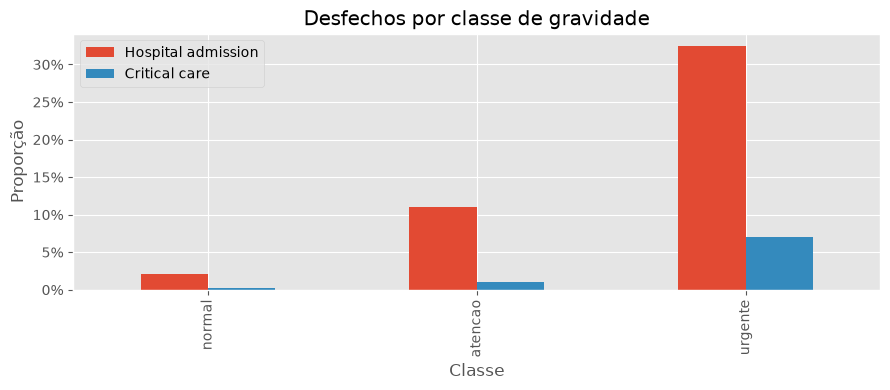

In [7]:
data["hospital_admission"] = data["ADMITHOS"].eq(1) | data["OBSHOS"].eq(1)
data["critical_care_admission"] = data["ADMIT"].eq(1)
data["died_in_ed"] = data["DIEDED"].eq(1)

outcome_summary = data.groupby("target", observed=True).agg(
    visits=("target", "size"),
    admission_rate=("hospital_admission", "mean"),
    critical_care_rate=("critical_care_admission", "mean"),
    deaths_in_ed=("died_in_ed", "sum"),
    death_rate=("died_in_ed", "mean"),
)
display(
    outcome_summary.style.format({
        "admission_rate": "{:.1%}",
        "critical_care_rate": "{:.1%}",
        "death_rate": "{:.2%}",
    })
)

plot_outcomes = outcome_summary[["admission_rate", "critical_care_rate"]].rename(
    columns={"admission_rate": "Hospital admission", "critical_care_rate": "Critical care"}
)
fig, ax = plt.subplots(figsize=(9, 4))
plot_outcomes.plot.bar(ax=ax)
ax.set(title="Desfechos por classe de gravidade", xlabel="Classe", ylabel="Proporção")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

## 6. Sinais vitais e gravidade

Medianas não substituem faixas clínicas nem capturam extremos, mas
ajudam a verificar diferenças agregadas entre as classes.

temperature_f       heart_rate       respiratory_rate        \
               median count     median count           median count   
target                                                                
normal           98.2  3102       88.0  3116             18.0  3102   
atencao          98.2  5266       87.0  5327             18.0  5330   
urgente          98.2  1744       90.0  1826             18.0  1820   

        systolic_bp       oxygen_saturation       pain_scale        
             median count            median count     median count  
target                                                              
normal        130.0  2791              98.0  3067        5.0  2328  
atencao       134.0  5195              98.0  5322        5.0  4162  
urgente       135.0  1788              98.0  1824        3.0  1234

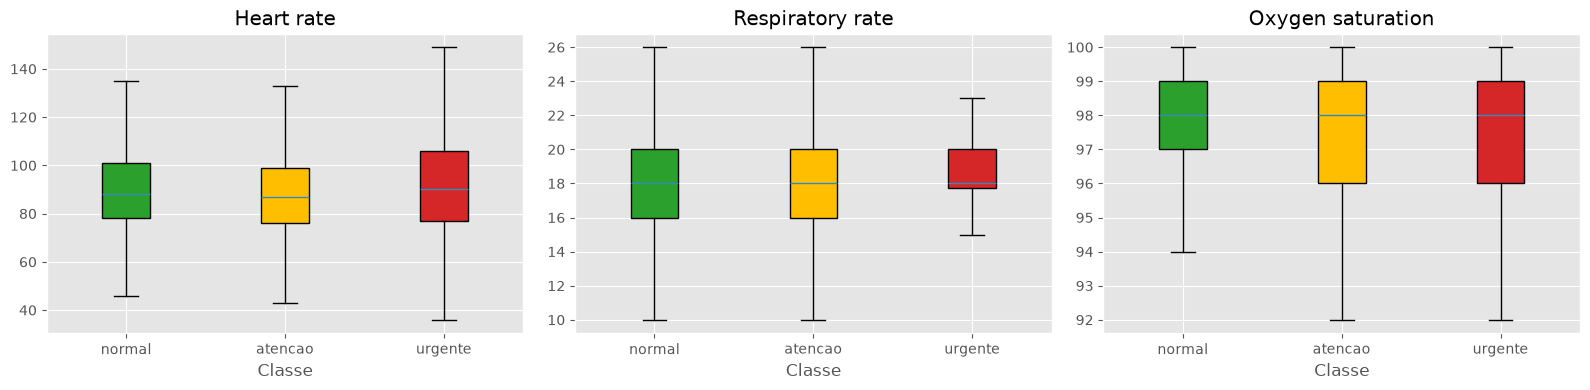

In [8]:
vital_columns = [
    "temperature_f",
    "heart_rate",
    "respiratory_rate",
    "systolic_bp",
    "oxygen_saturation",
    "pain_scale",
]
vital_summary = data.groupby("target", observed=True)[vital_columns].agg(["median", "count"])
display(vital_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, column, title in zip(
    axes,
    ["heart_rate", "respiratory_rate", "oxygen_saturation"],
    ["Heart rate", "Respiratory rate", "Oxygen saturation"],
):
    values = [data.loc[data["target"] == target, column].dropna() for target in TARGET_ORDER]
    plot = axis.boxplot(values, tick_labels=TARGET_ORDER, showfliers=False, patch_artist=True)
    for box, target in zip(plot["boxes"], TARGET_ORDER):
        box.set_facecolor(TARGET_COLORS[target])
    axis.set(title=title, xlabel="Classe", ylabel="")
plt.tight_layout()
plt.show()

## 7. Texto derivado e ambiguidade

Repetições e conflitos de rótulo ajudam a estimar o teto de desempenho
e orientar a futura estratégia de split.

In [9]:
examples = (
    data.dropna(subset=["RFV1_description"]).sort_values(["target", "RFV1"])
    .groupby("target", observed=True)
    .head(2)[["clinical_text", "target"]]
)
display(examples)

data["complaint_signature"] = data[complaint_columns].fillna("").agg(" | ".join, axis=1)
text_groups = data.groupby("clinical_text", dropna=False).agg(
    rows=("target", "size"),
    distinct_targets=("target", "nunique"),
)
complaint_groups = data.groupby("complaint_signature", dropna=False).agg(
    rows=("target", "size"),
    distinct_targets=("target", "nunique"),
)

ambiguity = pd.DataFrame(
    [
        {"representation": "Full derived clinical text", "unique_values": len(text_groups), "repeated_values": int((text_groups['rows'] > 1).sum()), "conflicting_values": int((text_groups['distinct_targets'] > 1).sum())},
        {"representation": "Complaint signature only", "unique_values": len(complaint_groups), "repeated_values": int((complaint_groups['rows'] > 1).sum()), "conflicting_values": int((complaint_groups['distinct_targets'] > 1).sum())},
    ]
)
display(ambiguity)

primary_complaint_table = pd.crosstab(data["RFV1_description"], data["target"])
primary_complaint_majority_accuracy = primary_complaint_table.max(axis=1).sum() / len(data)
print(
    "Acurácia aparente de uma regra que memoriza a classe majoritária por queixa principal: "
    f"{primary_complaint_majority_accuracy:.1%}"
)

,clinical_text,target
120,"Age: 26 years. Sex: Male. Reasons for visit: Chills; Shortness of breath; Diarrhea; Fever; COVID-19, virus not identified. Triage observ...",normal
5552,Age: 11 years. Sex: Female. Reasons for visit: Chills; Nausea; Vomiting. Triage observations: temperature 96.4 F; heart rate 83 bpm; res...,normal
508,"Age: 25 years. Sex: Male. Reasons for visit: Chills; Headache, pain in head; Nausea. Triage observations: temperature 97.3 F; heart rate...",atencao
644,Age: 31 years. Sex: Female. Reasons for visit: Chills; Chest pain; Cough; Vomiting; Personal history of COVID-19. Triage observations: t...,atencao
940,Age: 75 years. Sex: Male. Reasons for visit: Chills; Vertigo - dizziness; Shortness of breath; Leg symptoms; Discoloration or abnormal p...,urgente
4661,"Age: 32 years. Sex: Female. Reasons for visit: Chills; Side pain, flank pain; Back pain, ache, soreness, discomfort; Other vaginal sympt...",urgente


,representation,unique_values,repeated_values,conflicting_values
0,Full derived clinical text,10492,3,0
1,Complaint signature only,6401,674,457


Acurácia aparente de uma regra que memoriza a classe majoritária por queixa principal: 63.1%


## 8. Conclusão clínica

In [10]:
urgent_cases = int((data["target"] == "urgente").sum())
admission_monotonic = (
    outcome_summary["admission_rate"].is_monotonic_increasing
)
conflicting_clinical_texts = int(
    (text_groups["distinct_targets"] > 1).sum()
)

display(
    Markdown(
        f"""
        ### Principais achados

        - **Gravidade:** há {urgent_cases:,} casos `urgente`; o desbalanceamento de {imbalance_ratio:.2f}x reforça macro F1 e recall de `urgente` como métricas centrais.
        - **Sintomas:** motivos frequentes aparecem em mais de uma classe. Queixa isolada não determina prioridade.
        - **Doenças:** os diagnósticos ajudam a explicar apresentações e gravidade, mas permanecem bloqueados como features.
        - **Validação externa:** a internação cresce de forma monotônica entre as classes: **{admission_monotonic}**.
        - **Sinais vitais:** as distribuições agregadas mudam com a gravidade, mas extremos e ausência precisam ser preservados.
        - **Texto:** existem {conflicting_clinical_texts:,} textos derivados repetidos associados a mais de um target; textos idênticos devem permanecer no mesmo split.
        - **Vazamento:** diagnóstico, exames, medicamentos, espera, disposição, internação, UTI e óbito ficam restritos à EDA.

        ### Decisão

        A exploração sustenta o **NHAMCS-ED 2021 como base do demonstrador acadêmico**. O classificador deve receber texto clínico em inglês, usar split estratificado e agrupado pelo hash de `clinical_text` e declarar que a entrada é uma representação determinística de campos estruturados, não a fala livre original.
        """
    )
)


        ### Principais achados

        - **Gravidade:** há 1,880 casos `urgente`; o desbalanceamento de 2.89x reforça macro F1 e recall de `urgente` como métricas centrais.
        - **Sintomas:** motivos frequentes aparecem em mais de uma classe. Queixa isolada não determina prioridade.
        - **Doenças:** os diagnósticos ajudam a explicar apresentações e gravidade, mas permanecem bloqueados como features.
        - **Validação externa:** a internação cresce de forma monotônica entre as classes: **True**.
        - **Sinais vitais:** as distribuições agregadas mudam com a gravidade, mas extremos e ausência precisam ser preservados.
        - **Texto:** existem 0 textos derivados repetidos associados a mais de um target; textos idênticos devem permanecer no mesmo split.
        - **Vazamento:** diagnóstico, exames, medicamentos, espera, disposição, internação, UTI e óbito ficam restritos à EDA.

        ### Decisão

        A exploração sustenta o **NHAMCS-ED 2021 como base do demonstrador acadêmico**. O classificador deve receber texto clínico em inglês, usar split estratificado e agrupado pelo hash de `clinical_text` e declarar que a entrada é uma representação determinística de campos estruturados, não a fala livre original.
        